Testing out some different zero-padding schemes and ideas

In [10]:
## import statements:
import numpy as np
from matplotlib.pyplot import *
from numpy.fft import fft2
from numpy.fft import ifft2
from numpy.fft import fftshift
from numpy.fft import ifftshift
from scipy.interpolate import griddata


import pandas
from matplotlib.colors import LogNorm

from scipy.interpolate import RectBivariateSpline

import NF2FF as nf

import pykrige.kriging_tools as kt
from pykrige.ok import OrdinaryKriging

In [11]:
dat=np.load("f354cplxEfield.npz")
NF_EW_Complex=dat['cplxEfieldEW']
NF_NS_Complex=dat['cplxEfieldNS']

print(NF_EW_Complex.shape)
print(NF_NS_Complex.shape)

(86, 86)
(86, 86)


In [25]:
# making the gridding--without padding

M=NF_EW_Complex.shape[0]
N=NF_EW_Complex.shape[1]
dx = 0.33
dy = 0.33
dtheta = 0.05 # before was at 0.05
dphi = 0.05

In [13]:
# frequency stuff
k0 = nf.Calculate_k0(661*(10**6))
nyquist_m = nf.NyquistSampling(661*(10**6))

print(nyquist_m)

0.22677190468986383


## Trying some interpolation

We make a generic x, y grid (for all data) and use np.isnan to select for data points with no nan. Use these as the starting point for interpolation and interpolate to the full x, y grid. Cubic interpolation seems to work best, with `scipy.interpolate.griddata`.

In [14]:
# making grids
x=np.linspace(0,86,86)
y=np.linspace(0,86,86)
[x_grid,y_grid]=np.meshgrid(x,y)

In [15]:
# finding and selecting data points with no nans
EW_nan_boolean = np.isnan(NF_EW_Complex)
EW_notnan_boolean = np.invert(EW_nan_boolean)
NS_nan_boolean = np.isnan(NF_NS_Complex)
NS_notnan_boolean = np.invert(NS_nan_boolean)

NF_EW_Complex_selected = NF_EW_Complex[EW_notnan_boolean]
x_EW_grid_selected = x_grid[EW_notnan_boolean]
y_EW_grid_selected = y_grid[EW_notnan_boolean]

NF_NS_Complex_selected = NF_NS_Complex[NS_notnan_boolean]
x_NS_grid_selected = x_grid[NS_notnan_boolean]
y_NS_grid_selected = y_grid[NS_notnan_boolean]

In [16]:
# performing the interpolation--real and imaginary separately
NF_EW_real_selected = NF_EW_Complex_selected.real
NF_EW_im_selected = NF_EW_Complex_selected.imag
NF_NS_real_selected = NF_NS_Complex_selected.real
NF_NS_im_selected = NF_NS_Complex_selected.imag

In [17]:
# trying cubic interpolation
NF_EW_real_interp_cubic = griddata((x_EW_grid_selected,y_EW_grid_selected),NF_EW_real_selected,(x_grid,y_grid),fill_value=0,method='cubic')
NF_NS_real_interp_cubic = griddata((x_NS_grid_selected,y_NS_grid_selected),NF_NS_real_selected,(x_grid,y_grid),fill_value=0,method='cubic')
NF_EW_im_interp_cubic = griddata((x_EW_grid_selected,y_EW_grid_selected),NF_EW_im_selected,(x_grid,y_grid),fill_value=0,method='cubic')
NF_NS_im_interp_cubic = griddata((x_NS_grid_selected,y_NS_grid_selected),NF_NS_im_selected,(x_grid,y_grid),fill_value=0,method='cubic')

In [21]:
# putting interpolated data together into complex arrays

NF_EW_interped_cubic = NF_EW_real_interp_cubic + 1j*NF_EW_im_interp_cubic
NF_NS_interped_cubic = NF_NS_real_interp_cubic + 1j*NF_NS_im_interp_cubic

<ipython-input-21-3abda4462d09>:2: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax[0][0].pcolormesh(x_grid,y_grid,NF_EW_real_interp_cubic)
<ipython-input-21-3abda4462d09>:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = ax[0][1].pcolormesh(x_grid,y_grid,NF_NS_real_interp_cubic)
<ipython-input-21-3abda4462d09>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the co

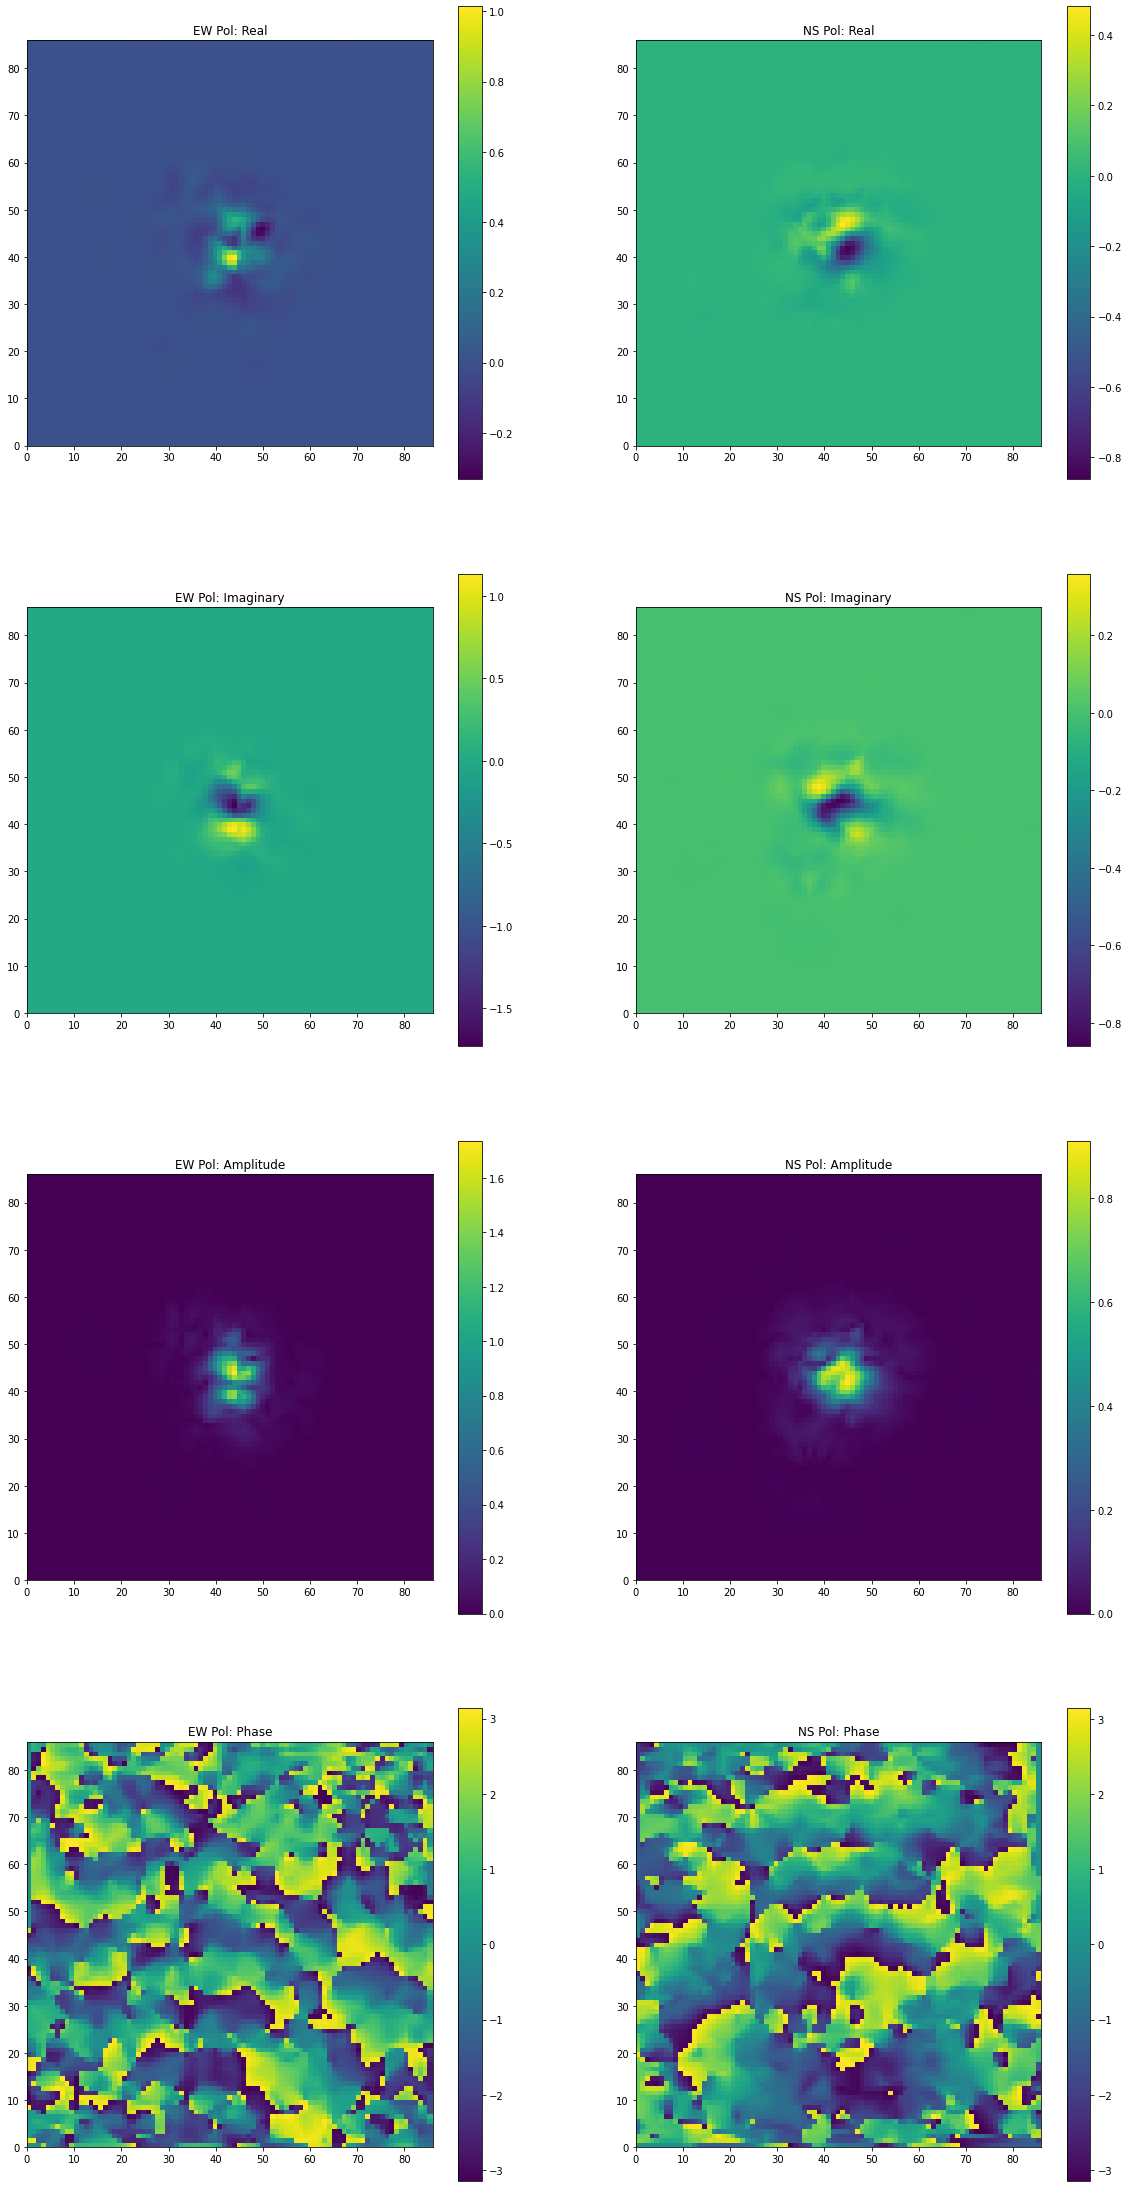

In [21]:
fig,ax=subplots(4,2,figsize=(20,40))
pcm = ax[0][0].pcolormesh(x_grid,y_grid,NF_EW_real_interp_cubic)
ax[0][0].set_title('EW Pol: Real')
colorbar(mappable=pcm,ax=ax[0][0])
pcm = ax[0][1].pcolormesh(x_grid,y_grid,NF_NS_real_interp_cubic)
ax[0][1].set_title('NS Pol: Real')
colorbar(mappable=pcm,ax=ax[0][1])
pcm = ax[1][0].pcolormesh(x_grid,y_grid,NF_EW_im_interp_cubic)
ax[1][0].set_title('EW Pol: Imaginary')
colorbar(mappable=pcm,ax=ax[1][0])
pcm = ax[1][1].pcolormesh(x_grid,y_grid,NF_NS_im_interp_cubic)
ax[1][1].set_title('NS Pol: Imaginary')
colorbar(mappable=pcm,ax=ax[1][1])
pcm = ax[2][0].pcolormesh(x_grid,y_grid,np.abs(NF_EW_interped_cubic))
ax[2][0].set_title('EW Pol: Amplitude')
colorbar(mappable=pcm,ax=ax[2][0])
pcm = ax[2][1].pcolormesh(x_grid,y_grid,np.abs(NF_NS_interped_cubic))
ax[2][1].set_title('NS Pol: Amplitude')
colorbar(mappable=pcm,ax=ax[2][1])
pcm = ax[3][0].pcolormesh(x_grid,y_grid,np.angle(NF_EW_interped_cubic))
ax[3][0].set_title('EW Pol: Phase')
colorbar(mappable=pcm,ax=ax[3][0])
pcm = ax[3][1].pcolormesh(x_grid,y_grid,np.angle(NF_NS_interped_cubic))
ax[3][1].set_title('NS Pol: Phase')
colorbar(mappable=pcm,ax=ax[3][1])
for axis_set in ax:
    for a in axis_set:
        a.set_aspect('equal')

Can't use the RegularGridding function for this because of how the data is, so will make the gridding myself in the next cell(s)

In [26]:
# setting up k-space, theta, phi grids
# See equations (16-13a) and (16-13b) in Balanis
# Zero padding is used to increase the resolution of the plane wave spectral domain.
MI=4*M;#2^(ceil(log2(M))+1);
NI=4*N;#2^(ceil(log2(N))+1);
m=np.linspace(-MI/2,MI/2-1,MI);
n=np.linspace(-NI/2,NI/2-1,NI)
k_X_Rectangular=(2*np.pi*m)/(MI*dx);
k_Y_Rectangular=(2*np.pi*n)/(NI*dy);
theta=np.arange(0,np.pi/2+dtheta,dtheta);
phi=np.arange(0,2*np.pi+dphi,dphi);
[theta,phi]=np.meshgrid(theta,phi);

In [84]:
# making padded versions:
pad_amount = 15
x_padded50 = np.concatenate((np.arange(x[0]-(pad_amount+1)*dx,x[0]-dx,dx),x,np.arange(x[-1]+dx,x[-1]+dx+pad_amount*dx,dx)))
y_padded50 = np.concatenate((np.arange(y[0]-(pad_amount+1)*dy,y[0]-dy,dy),y,np.arange(y[-1]+dy,y[-1]+dy+pad_amount*dy,dy)))
NF_EW_interped_cubic_padded50 = np.pad(NF_EW_interped_cubic,pad_amount,mode='constant')
NF_NS_interped_cubic_padded50 = np.pad(NF_NS_interped_cubic,pad_amount,mode='constant')
[x_grid_padded50, y_grid_padded50] = np.meshgrid(x_padded50,y_padded50)

In [85]:
print(x.shape)
print(y.shape)
print(NF_EW_interped_cubic.shape)
print(NF_EW_interped_cubic.shape)
print(x_padded50.shape)
print(y_padded50.shape)
print(np.arange(x[0]-(pad_amount+1)*dx,x[0]-dx,dx).shape)
print(np.arange(x[-1]+dx,x[-1]+dx+pad_amount*dx,dx).shape)
print(NF_EW_interped_cubic_padded50.shape)
print(NF_NS_interped_cubic_padded50.shape)

(86,)
(86,)
(86, 86)
(86, 86)
(117,)
(117,)
(15,)
(16,)
(116, 116)
(116, 116)


TypeError: Dimensions of C (286, 286) are incompatible with X (285) and/or Y (285); see help(pcolormesh)

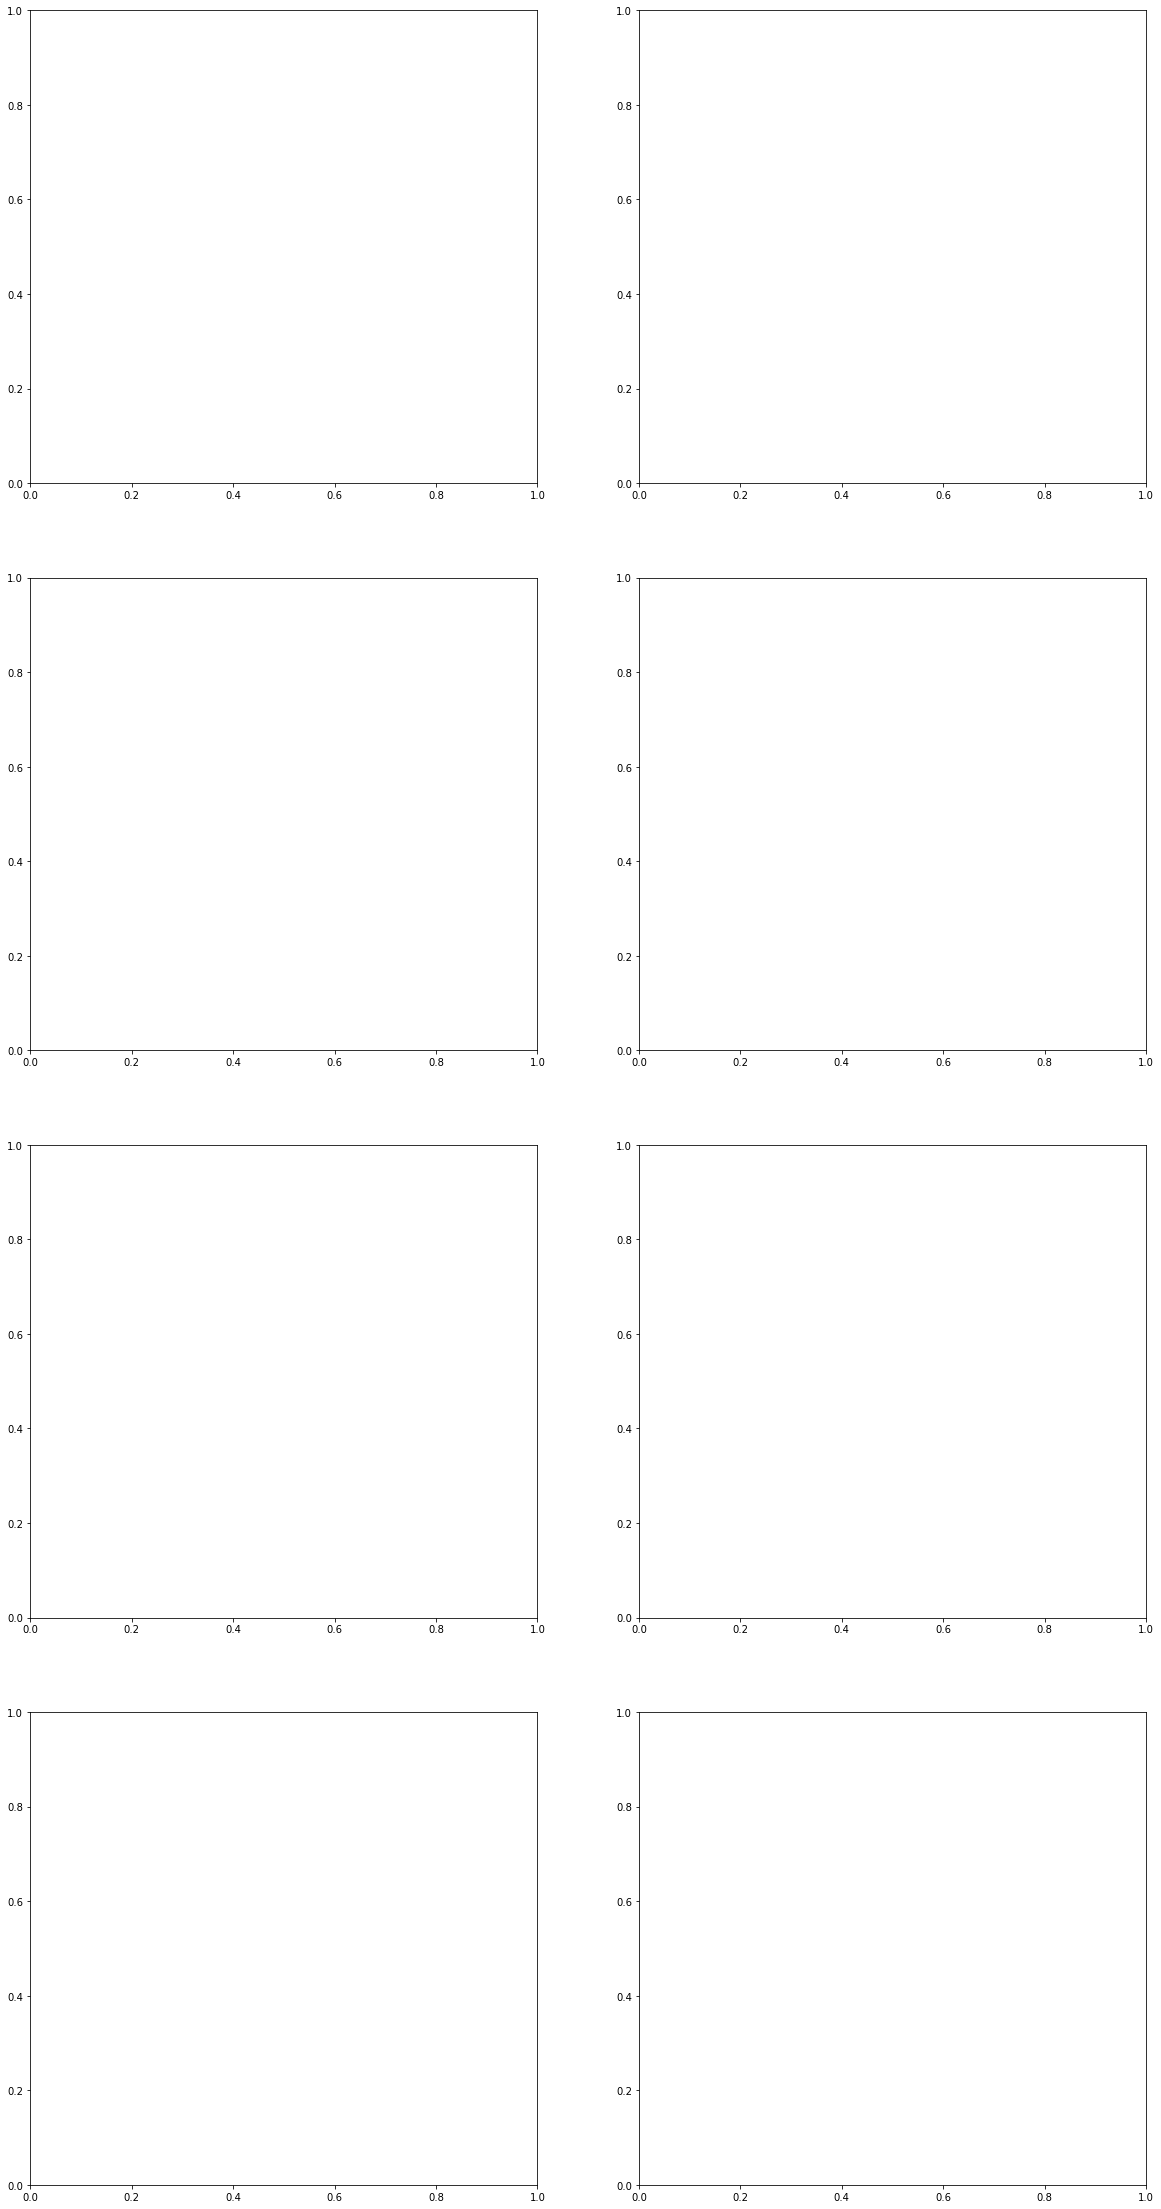

In [38]:
fig,ax=subplots(4,2,figsize=(20,40))
pcm = ax[0][0].pcolormesh(x_grid_padded50,y_grid_padded50,NF_EW_interped_cubic_padded50.real)
ax[0][0].set_title('EW Pol: Real')
colorbar(mappable=pcm,ax=ax[0][0])
pcm = ax[0][1].pcolormesh(x_grid_padded50,y_grid_padded50,NF_NS_interped_cubic_padded50.real)
ax[0][1].set_title('NS Pol: Real')
colorbar(mappable=pcm,ax=ax[0][1])
pcm = ax[1][0].pcolormesh(x_grid_padded50,y_grid_padded50,NF_EW_interped_cubic_padded50.imag)
ax[1][0].set_title('EW Pol: Imaginary')
colorbar(mappable=pcm,ax=ax[1][0])
pcm = ax[1][1].pcolormesh(x_grid_padded50,y_grid_padded50,NF_NS_interped_cubic_padded50.imag)
ax[1][1].set_title('NS Pol: Imaginary')
colorbar(mappable=pcm,ax=ax[1][1])
pcm = ax[2][0].pcolormesh(x_grid_padded50,y_grid_padded50,np.abs(NF_EW_interped_cubic_padded50))
ax[2][0].set_title('EW Pol: Amplitude')
colorbar(mappable=pcm,ax=ax[2][0])
pcm = ax[2][1].pcolormesh(x_grid_padded50,y_grid_padded50,np.abs(NF_NS_interped_cubic_padded50))
ax[2][1].set_title('NS Pol: Amplitude')
colorbar(mappable=pcm,ax=ax[2][1])
pcm = ax[3][0].pcolormesh(x_grid_padded50,y_grid_padded50,np.angle(NF_EW_interped_cubic_padded50))
ax[3][0].set_title('EW Pol: Phase')
colorbar(mappable=pcm,ax=ax[3][0])
pcm = ax[3][1].pcolormesh(x_grid_padded50,y_grid_padded50,np.angle(NF_NS_interped_cubic_padded50))
ax[3][1].set_title('NS Pol: Phase')
colorbar(mappable=pcm,ax=ax[3][1])
for axis_set in ax:
    for a in axis_set:
        a.set_aspect('equal')

In [35]:
M_padded30 = len(x_padded30)
N_padded30 = len(y_padded30)
MI_padded30=4*M_padded30;#2^(ceil(log2(M))+1);
NI_padded30=4*N_padded30;#2^(ceil(log2(N))+1);
m_padded30=np.linspace(-MI_padded30/2,MI_padded30/2-1,MI_padded30);
n_padded30=np.linspace(-NI_padded30/2,NI_padded30/2-1,NI_padded30)
k_X_Rectangular_padded30=(2*np.pi*m_padded30)/(MI_padded30*dx);
k_Y_Rectangular_padded30=(2*np.pi*n_padded30)/(NI_padded30*dy);
theta=np.arange(0,np.pi/2+dtheta,dtheta);
phi=np.arange(0,2*np.pi+dphi,dphi);
[theta,phi]=np.meshgrid(theta,phi);

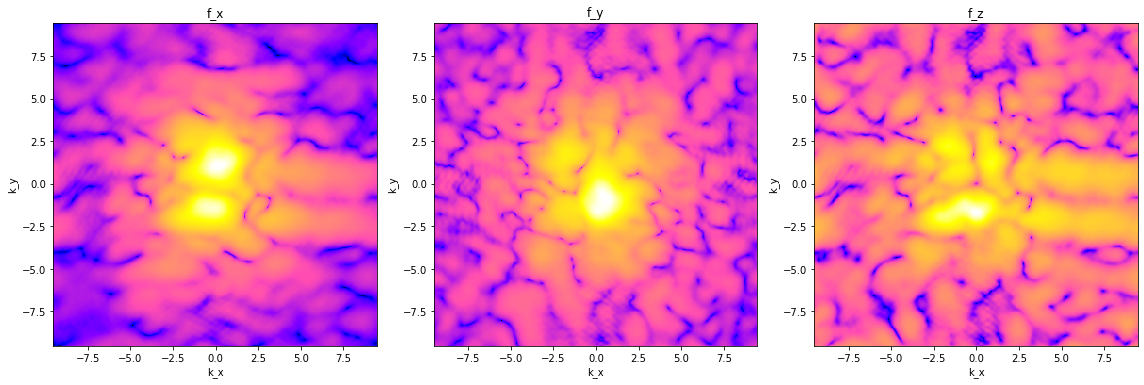

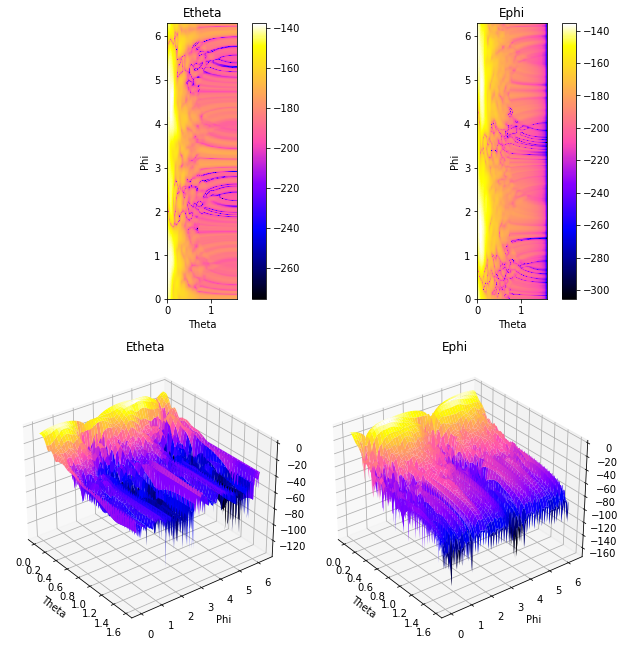

In [22]:
FourierSpace=nf.NFtoFourier(NF_EW_interped_cubic,NF_NS_interped_cubic,k_X_Rectangular,k_Y_Rectangular,k0,plotFourier=True)

[Etheta,Ephi]=nf.FouriertoFF(FourierSpace[0],FourierSpace[1],FourierSpace[2],theta,phi,k_X_Rectangular,k_Y_Rectangular,k0,FFOutputs=True)

/home/am3674/NF2FF_WL/NF2FF.py:92: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax1.pcolormesh(kx_grid,ky_grid,fx_magnitude,cmap='gnuplot2',norm=LogNorm())
/home/am3674/NF2FF_WL/NF2FF.py:93: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax2.pcolormesh(kx_grid,ky_grid,fy_magnitude,cmap='gnuplot2',norm=LogNorm())
/home/am3674/NF2FF_WL/NF2FF.py:94: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3. 

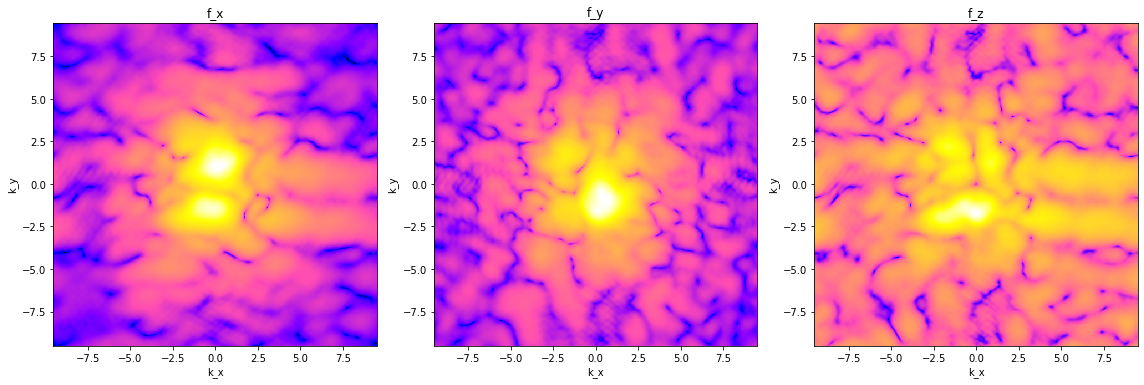

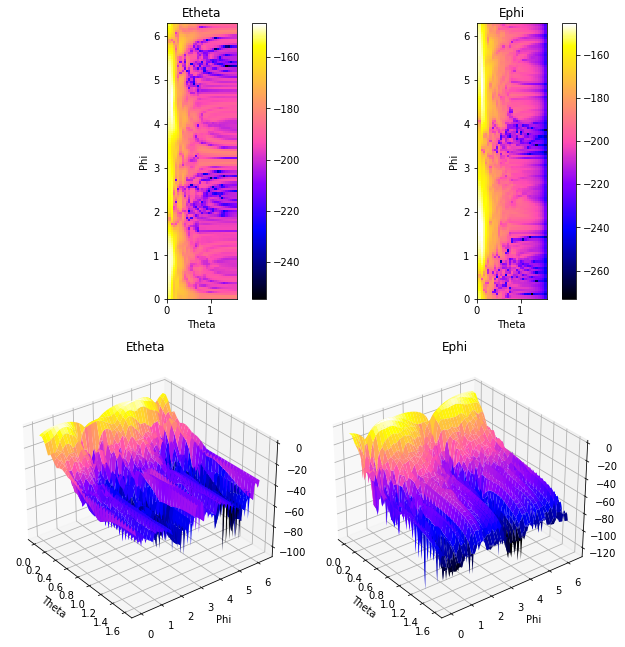

In [36]:
FourierSpace_padded30=nf.NFtoFourier(NF_EW_interped_cubic_padded30,NF_NS_interped_cubic_padded30,k_X_Rectangular_padded30,k_Y_Rectangular_padded30,k0,plotFourier=True)

[Etheta_padded30,Ephi_padded30]=nf.FouriertoFF(FourierSpace_padded30[0],FourierSpace_padded30[1],FourierSpace_padded30[2],theta,phi,k_X_Rectangular_padded30,k_Y_Rectangular_padded30,k0,FFOutputs=True)

In [23]:
print(np.count_nonzero(np.isnan(NF_EW_interped)))
print(np.count_nonzero(np.isnan(NF_NS_interped)))

0
0


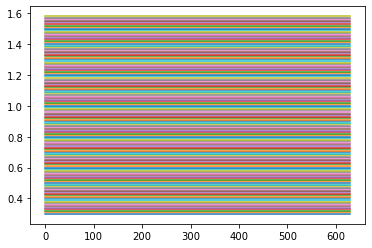

In [24]:
Ephi.shape,phi.shape,theta.shape
plot(theta[:,30:])

<ipython-input-25-e7fbcdf550d6>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Etheta[:,:])),cmap='gnuplot2')
<ipython-input-25-e7fbcdf550d6>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Ephi[:,:])),cmap='gnuplot2')


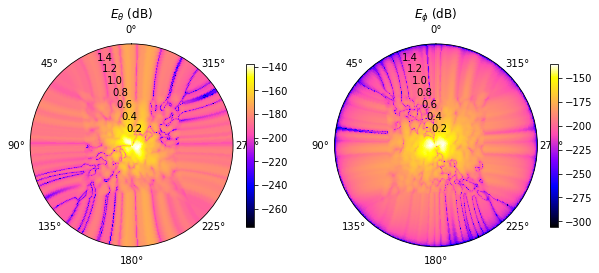

In [25]:
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Etheta[:,:])),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')
ax.set_theta_offset(np.pi/2.0)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi[:,:],theta[:,:],20*np.log10(np.abs(Ephi[:,:])),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_theta_offset(np.pi/2.0)

<ipython-input-26-c70c49f5550e>:3: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
<ipython-input-26-c70c49f5550e>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')


(0.0, 1.0)

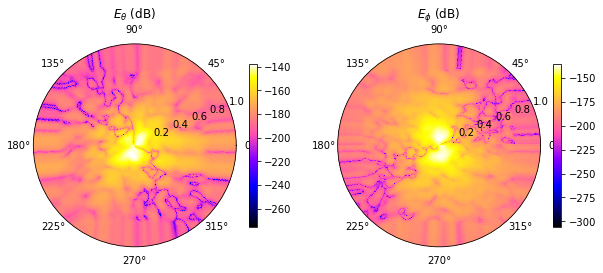

In [26]:
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_ylim(0,1)
ax.set_title(r'$E_{\theta}$ (dB)')
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi,theta,20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_ylim(0,1)

[[0.   0.   0.   ... 0.   0.   0.  ]
 [0.01 0.01 0.01 ... 0.01 0.01 0.01]
 [0.02 0.02 0.02 ... 0.02 0.02 0.02]
 ...
 [6.27 6.27 6.27 ... 6.27 6.27 6.27]
 [6.28 6.28 6.28 ... 6.28 6.28 6.28]
 [6.29 6.29 6.29 ... 6.29 6.29 6.29]]


<ipython-input-27-68835ef128d3>:5: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
<ipython-input-27-68835ef128d3>:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Ephi)),cmap='gnuplot2')


(0.0, 1.0)

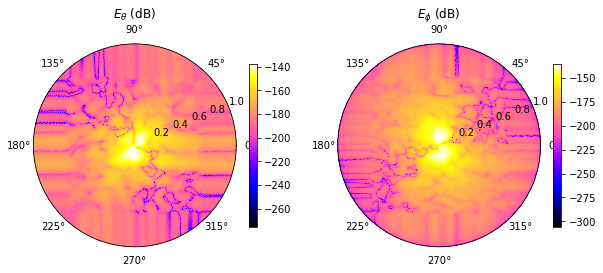

In [27]:
print (phi)
# trying to project from polar onto the xy plane
fig = figure(figsize=(10,10))
ax = subplot(1, 2, 1, projection='polar')
pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Etheta)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')
ax.set_ylim(0,1)
ax = subplot(1, 2, 2, projection='polar')
pcm = pcolormesh(phi,np.abs(np.sin(theta)),20*np.log10(np.abs(Ephi)),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')
ax.set_ylim(0,1)

[]

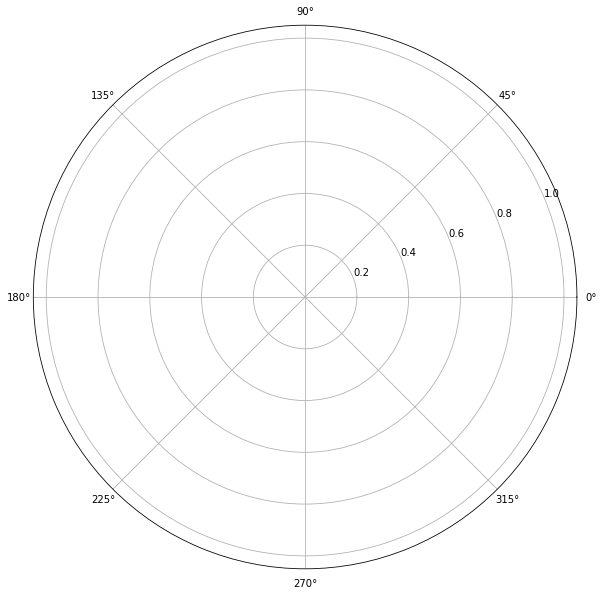

In [139]:
fig = figure(figsize = (10,10))
ax = subplot(1,1,1,projection = 'polar')
data = np.ones(len(theta))
polar()

/home/am3674/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:171: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0.5, 0.92, '$E_{\\phi}$ (dB)')

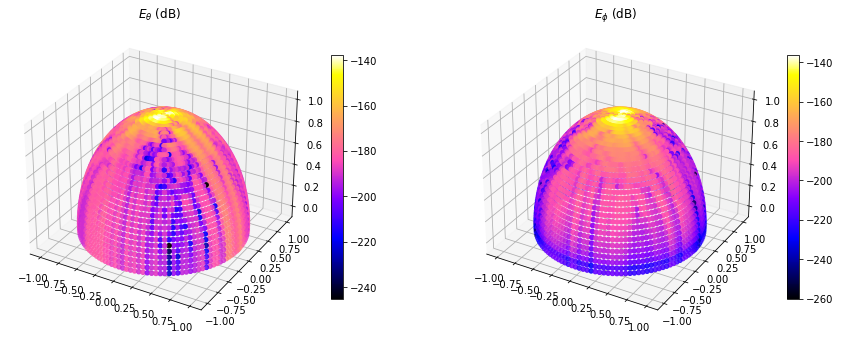

In [140]:
fig = figure(figsize=(15,15))
ax = subplot(1,2,1,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Etheta
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.scatter(X, Y, zs=Z,c=20*np.log10(Etheta),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')

ax = subplot(1,2,2,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Ephi
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.scatter(X, Y, zs=Z,c=20*np.log10(Ephi),cmap='gnuplot2')
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')

/home/am3674/anaconda3/lib/python3.8/site-packages/matplotlib/colors.py:271: ComplexWarning: Casting complex values to real discards the imaginary part
  c = tuple(map(float, c))
/home/am3674/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0.92, '$E_{\\phi}$ (dB)')

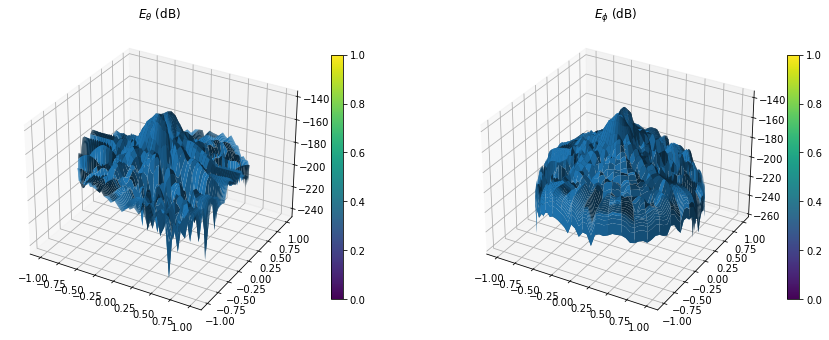

In [141]:
fig = figure(figsize=(15,15))
ax = subplot(1,2,1,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Etheta
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.plot_surface(X, Y,20*np.log10(Etheta))
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\theta}$ (dB)')

ax = subplot(1,2,2,projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
R = Ephi
# Express the mesh in the cartesian system.
X = np.sin(theta)*np.cos(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(theta)

# Plot the surface.
pcm = ax.plot_surface(X, Y, 20*np.log10(Ephi))
colorbar(mappable = pcm,shrink = 0.3)
ax.set_title(r'$E_{\phi}$ (dB)')